# Parte 2 — Experimento de PLN distribuído

Nesta etapa, o objetivo é implementar e analisar um **pipeline de Processamento de Linguagem Natural (PLN) distribuído**, avaliando seu comportamento com diferentes quantidades de workers no cluster.

O experimento utiliza o dataset **B2W-Reviews01**, composto por avaliações textuais de consumidores, permitindo observar como tarefas de PLN se comportam em um cenário com maior volume de dados.

O pipeline possui quatro etapas principais:

1. **Tokenização:** separação dos textos em tokens;
2. **Remoção de stopwords:** eliminação de termos frequentes e pouco informativos;
3. **Vetorização TF-IDF:** transformação dos documentos em representações numéricas ponderadas pela relevância dos termos;
4. **Estatísticas do corpus:** cálculo de informações como tamanho do vocabulário, tamanho dos documentos e termos de maior relevância.

O desempenho foi avaliado utilizando **1, 2, 4, 8, 16 e 32 workers**. A principal métrica utilizada é o **speedup**, comparando o ganho observado com o cenário ideal de crescimento linear.

A análise também considera a **Lei de Amdahl**, utilizada para investigar como partes sequenciais do pipeline podem limitar os ganhos de paralelização.

Entre os possíveis gargalos avaliados estão comunicação entre workers, serialização, operações de shuffle, acesso ao NFS, limitações de rede, hyperthreading e etapas que não podem ser completamente paralelizadas.

## Organização do notebook

O notebook acompanha todo o fluxo do experimento, incluindo:

- preparação e validação do dataset;
- implementação do pipeline de PLN;
- testes locais das funções;
- configuração da execução distribuída;
- leitura dos resultados obtidos via SLURM;
- cálculo dos tempos medianos e speedups;
- comparação com o experimento `pi_mpi`;
- visualização dos resultados;
- análise dos gargalos e aplicação da Lei de Amdahl.

## Modos de execução

O notebook pode ser utilizado em dois modos.

### Execução local

A execução local utiliza uma **amostra reduzida dos dados**, destinada à validação da tokenização, remoção de stopwords, TF-IDF, estatísticas, tratamento dos resultados e geração dos gráficos.

Esse modo serve para verificar o funcionamento do pipeline, mas **não representa o experimento completo de desempenho**.

### Execução no cluster

Para realizar uma nova execução distribuída, deve-se configurar:

```python
EXECUTAR_CLUSTER = True
```

e seguir as instruções disponíveis no `README.md`.

As execuções completas são submetidas ao cluster por meio do **SLURM**. Os resultados analisados neste notebook correspondem à rodada previamente executada nos **jobs 122 a 127**.

As conclusões apresentadas representam a **análise geral do grupo**. As análises individuais permanecem separadas na pasta `analise/`.

## 1. Ambiente e caminhos

Antes de iniciar o processamento, configuramos o ambiente e os caminhos utilizados no experimento, garantindo consistência entre o notebook e as execuções realizadas no cluster.

As dependências estão definidas em `pipeline/requirements.txt`. As principais versões utilizadas foram:

- **Python 3.11.16**
- **NumPy 2.4.6**
- **Dask 2026.8.0**
- **Distributed 2026.8.0**
- **JupyterLab 4.6.4**
- **Matplotlib 3.11.2**

No cluster, o ambiente `hpc` está disponível em:

```text
/opt/ohpc/pub/apps/miniforge3
```

Como esse ambiente é compartilhado entre os nós, todos os workers utilizam as mesmas versões das bibliotecas.

Para executar o notebook no nó master:

```bash
source /opt/ohpc/pub/apps/miniforge3/bin/activate hpc
cd /home/g02/P-HPC-1/pipeline
jupyter lab --no-browser --ip=127.0.0.1 --port=8888 experimento_pln.ipynb
```

### Dask no experimento

O processamento distribuído utiliza **Dask** para dividir o trabalho entre diferentes workers.

No notebook, os testes utilizam um `LocalCluster`, permitindo validar o funcionamento do pipeline com múltiplos workers. Já no benchmark completo, os workers são processos executados nos nós reservados pelo **SLURM**.

Assim, os testes locais verificam principalmente a **correção da implementação**, enquanto as execuções no cluster são utilizadas para avaliar o **desempenho distribuído**.

### Caminhos utilizados

A raiz do repositório (`REPO`) é identificada automaticamente a partir do arquivo `pipeline/dataset-manifest.json`. A partir dela, são definidos os principais caminhos:

```python
PIPELINE_DIR = REPO / 'pipeline'
DATASET_DIR = Path('/opt/ohpc/pub/datasets/b2w-reviews01')
EVIDENCIAS = REPO / 'resultados/pipeline/run-20260930-corpus02'
CSV_MEDIANAS = REPO / 'resultados/speedup_corpus.csv'
```

- `PIPELINE_DIR`: scripts e notebook do pipeline;
- `DATASET_DIR`: dataset armazenado no NFS;
- `EVIDENCIAS`: resultados da execução utilizada na análise;
- `CSV_MEDIANAS`: tempos medianos das configurações testadas.

O dataset não é versionado no repositório e permanece no NFS, permitindo acesso compartilhado entre os nós do cluster.

### Controle da execução no cluster

A variável:

```python
EXECUTAR_CLUSTER = False
```

evita que a execução completa do notebook submeta novos jobs automaticamente.

Com `False`, é possível validar funções, executar testes locais, carregar resultados existentes e gerar análises. Para iniciar uma nova rodada distribuída, deve-se utilizar:

```python
EXECUTAR_CLUSTER = True
```

seguindo previamente as instruções do `README.md`.

### Rastreabilidade

O notebook também calcula um **hash SHA-256** das células de código:

```python
EXECUTOR_SHA256 = hashlib.sha256(
    '\n'.join(sources).encode()
).hexdigest()
```

Esse hash funciona como uma identificação da versão do código utilizada, contribuindo para a **rastreabilidade e reprodutibilidade** do experimento.

Esta etapa, portanto, prepara o ambiente, os caminhos e os controles necessários antes do processamento do corpus.

In [1]:
from collections import Counter
from contextlib import redirect_stdout
from datetime import datetime
from pathlib import Path
import csv
import hashlib
import io
import json
import math
import os
import re
import socket
import statistics
import subprocess
import tempfile
import time
import unicodedata
import unittest
import urllib.request
import zipfile

import numpy as np
import matplotlib.pyplot as plt
from distributed import Client, LocalCluster
from IPython.display import Markdown, display

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pipeline/dataset-manifest.json').is_file())
PIPELINE_DIR = REPO / 'pipeline'
DATASET_DIR = Path('/opt/ohpc/pub/datasets/b2w-reviews01')
EVIDENCIAS = REPO / 'resultados/pipeline/run-20260930-corpus02'
CSV_MEDIANAS = REPO / 'resultados/speedup_corpus.csv'
EXECUTAR_CLUSTER = False

notebook = json.loads((PIPELINE_DIR / 'experimento_pln.ipynb').read_text())
sources = [''.join(c['source']) for c in notebook['cells'] if c['cell_type'] == 'code']
EXECUTOR_SHA256 = hashlib.sha256('\n'.join(sources).encode()).hexdigest()
print('Repositório:', REPO)
print('Execução no cluster habilitada:', EXECUTAR_CLUSTER)


Repositório: /Users/marcoruas/Documents/INTELI/PONDERADAS/P-HPC-1
Execução no cluster habilitada: False


## 2. Dataset público e preparação

Para o experimento foi utilizado o **B2W-Reviews01**, um dataset público de avaliações de produtos em português brasileiro, originalmente disponibilizado pela B2W Digital.

O dataset possui mais de **130 mil avaliações**, e neste trabalho utilizamos apenas o campo textual `review_text`.

O conjunto original possui **132.373 registros**. Após remover avaliações sem texto válido, o corpus utilizado contém:

```text
129.098 documentos
```

Cada valor não vazio de `review_text` é tratado como um documento. Avaliações duplicadas são mantidas, pois o objetivo do experimento é avaliar o desempenho do pipeline distribuído, e não realizar limpeza semântica da base.

### Preparação do corpus

O arquivo CSV original possui aproximadamente **47,16 MiB**. Após a preparação, os documentos são armazenados em **128 shards no formato JSONL**, totalizando aproximadamente **20,44 MiB**.

Cada linha representa um documento, por exemplo:

```json
{"id": 42, "text": "Produto muito bom e chegou antes do prazo."}
```

A divisão em shards permite distribuir a leitura e o processamento entre diferentes workers. Os documentos são atribuídos às partições utilizando uma estratégia **round-robin**, buscando manter uma distribuição equilibrada da carga.

```text
documento 0 → shard 0
documento 1 → shard 1
...
documento 128 → shard 0
```

### Armazenamento no cluster

O corpus preparado é armazenado no NFS em:

```text
/opt/ohpc/pub/datasets/b2w-reviews01
```

Como o diretório é compartilhado entre os nós, todos os workers conseguem acessar os mesmos arquivos durante as execuções.

Esse modelo também pode introduzir contenção de **I/O**, já que vários workers podem acessar o NFS simultaneamente. Esse possível gargalo será considerado posteriormente na análise de desempenho.

### Processo de preparação

A preparação do corpus consiste, de forma resumida, em:

1. localizar e validar o dataset;
2. ler o CSV original;
3. selecionar valores válidos de `review_text`;
4. atribuir identificadores aos documentos;
5. distribuir os textos entre os 128 shards;
6. salvar os arquivos JSONL;
7. registrar metadados e hashes.

O notebook apenas define esse processo. A preparação efetiva é executada somente quando uma nova rodada do experimento é realizada, evitando recriar o corpus desnecessariamente.

### Reprodutibilidade

Hashes são utilizados para identificar os arquivos e garantir que todas as configurações de workers utilizem o mesmo **snapshot do dataset**.

Isso permite relacionar cada execução a uma versão específica tanto dos dados quanto do código, aumentando a rastreabilidade do experimento.

### Separação entre preparação e benchmark

A preparação do dataset **não é incluída no tempo do benchmark**. Antes das execuções com 1, 2, 4, 8, 16 e 32 workers, o corpus já está disponível no NFS.

Assim, os tempos analisados correspondem principalmente às etapas de:

```text
leitura dos shards
        ↓
tokenização
        ↓
remoção de stopwords
        ↓
TF-IDF
        ↓
estatísticas
```

Ao final desta etapa, temos um corpus de **129.098 documentos** organizado para processamento distribuído e compartilhado entre os nós do cluster.

In [2]:
COMMIT = '4639429ec698d7821fc99a0bc665fa213d9fcd5a'

CSV_URL = f'https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/{COMMIT}/B2W-Reviews01.csv'

CSV_SHA = '821fb0bf9f7230b0fba4e4f9fadd75a66d1a9ff0b1657810791d33007eb2ab38'

STOP_COMMIT = '550b6625bcef1f2abff2ff770a5a0d272c9c6b2a'

STOP_URL = f'https://raw.githubusercontent.com/nltk/nltk_data/{STOP_COMMIT}/packages/corpora/stopwords.zip'

STOP_SHA = '48c0e52d8b52546e827f53761fb30300c0ab94f70660d28bd65ba0a86270946b'

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def download(url, target, expected):
    if not target.exists():
        with urllib.request.urlopen(url, timeout=120) as response:
            data = response.read()
        if hashlib.sha256(data).hexdigest() != expected:
            raise ValueError(f'SHA-256 inesperado: {url}')
        target.write_bytes(data)
    if sha256(target) != expected:
        raise ValueError(f'Snapshot local alterado: {target}')

def prepare(directory, shards=128):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    raw = directory / 'B2W-Reviews01.csv'
    download(CSV_URL, raw, CSV_SHA)
    if (directory / 'manifest.json').exists():
        manifest = json.loads((directory / 'manifest.json').read_text())
        if manifest['partitions'] != shards or manifest['raw_sha256'] != CSV_SHA:
            raise ValueError('Preparação existente usa outro protocolo')
        for item in manifest['files']:
            if sha256(directory / item['path']) != item['sha256']:
                raise ValueError(f"Arquivo preparado alterado: {item['path']}")
        return manifest
    with urllib.request.urlopen(STOP_URL, timeout=120) as response:
        archive = response.read()
    if hashlib.sha256(archive).hexdigest() != STOP_SHA:
        raise ValueError('Snapshot de stopwords inesperado')
    words = zipfile.ZipFile(io.BytesIO(archive)).read('stopwords/portuguese').decode('utf-8').splitlines()
    stopwords = sorted({unicodedata.normalize('NFC', word).casefold() for word in words})
    stop = directory / 'stopwords-pt.txt'
    stop.write_text('\n'.join(stopwords) + '\n', encoding='utf-8')
    paths = [directory / f'part-{i:03d}.jsonl' for i in range(shards)]
    streams = [p.open('w', encoding='utf-8') for p in paths]
    rows = empty = documents = 0
    try:
        with raw.open(encoding='utf-8-sig', newline='') as f:
            reader = csv.DictReader(f, delimiter=',')
            if 'review_text' not in reader.fieldnames:
                raise ValueError('Coluna review_text ausente')
            for rows, row in enumerate(reader, 1):
                if None in row or row['review_text'] is None:
                    raise ValueError(f'Registro CSV inválido: {rows}')
                text = row['review_text'].strip()
                if not text:
                    empty += 1
                    continue
                record = {'id': rows, 'text': text}
                streams[documents % shards].write(json.dumps(record, ensure_ascii=False) + '\n')
                documents += 1
    finally:
        for stream in streams:
            stream.close()
    if documents < 50000:
        raise ValueError(f'Corpus insuficiente: {documents} documentos')
    files = [{'path': p.name, 'bytes': p.stat().st_size, 'sha256': sha256(p)} for p in [*paths, stop]]
    manifest = dict(source='https://github.com/americanas-tech/b2w-reviews01', commit=COMMIT,
                    raw_url=CSV_URL, raw_sha256=CSV_SHA, raw_bytes=raw.stat().st_size,
                    records=rows, excluded_empty=empty, documents=documents,
                    language='pt-BR', raw_format='CSV UTF-8, delimitador vírgula, aspas duplas',
                    document_field='review_text', partitions=shards, files=files,
                    prepared_bytes=sum(x['bytes'] for x in files), stopwords_count=len(stopwords),
                    stopwords_source=STOP_URL, stopwords_archive_sha256=STOP_SHA,
                    license='CC BY-NC-SA 4.0', attribution='B2W Digital — B2W-Reviews01')
    (directory / 'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2) + '\n')
    return manifest

In [3]:
manifest = json.loads((PIPELINE_DIR / 'dataset-manifest.json').read_text())
assert manifest['documents'] >= 50_000
for key in ['source', 'commit', 'records', 'documents', 'excluded_empty', 'raw_bytes', 'prepared_bytes', 'language', 'raw_format', 'partitions', 'stopwords_count']:
    print(f'{key}: {manifest[key]}')

source: https://github.com/americanas-tech/b2w-reviews01
commit: 4639429ec698d7821fc99a0bc665fa213d9fcd5a
records: 132373
documents: 129098
excluded_empty: 3275
raw_bytes: 49453175
prepared_bytes: 21430941
language: pt-BR
raw_format: CSV UTF-8, delimitador vírgula, aspas duplas
partitions: 128
stopwords_count: 207


## 3. Quatro etapas do pipeline

### 3.1 Tokenização e remoção de stopwords

A primeira etapa do pipeline transforma cada avaliação em uma sequência padronizada de termos.

Inicialmente, os textos passam por **normalização Unicode NFC** e por `casefold()`, garantindo maior consistência na representação de caracteres e eliminando diferenças entre maiúsculas e minúsculas.

A tokenização utiliza a expressão:

```python
TOKEN = re.compile(r'[^\W\d\_]+', re.UNICODE)
```

Ela seleciona sequências formadas por letras Unicode, preservando caracteres do português, como `á`, `ç` e `ã`, e descartando números, pontuação e `_`.

Em seguida, são removidas **207 stopwords em português**, utilizando uma lista fixa para garantir a reprodutibilidade entre execuções.

Para cada documento, um `Counter` registra a frequência dos termos restantes:

```python
counts = Counter(
    token for token in tokens
    if token not in stopwords
)
```

Essas contagens serão utilizadas posteriormente no cálculo do TF-IDF.

Além da frequência dos termos dentro de cada documento, cada partição calcula a **frequência documental (DF)**, que representa em quantos documentos diferentes cada termo aparece:

```python
frequency.update(counts.keys())
```

Dessa forma, um termo contribui apenas uma vez para o DF de cada documento, independentemente do número de ocorrências nele.

Também são registrados os tamanhos dos documentos **antes e depois da remoção de stopwords**, utilizados posteriormente nas estatísticas do corpus.

Documentos que ficam sem termos após a filtragem são mantidos e posteriormente representados por **vetores zero**, preservando a correspondência com o corpus original.

Como os dados estão divididos em shards, essa etapa pode ser executada independentemente por diferentes workers. Ao final, apenas os metadados necessários são combinados para o cálculo das estatísticas globais.

In [4]:
TOKEN = re.compile(r'[^\W\d_]+', re.UNICODE)

PROTOCOL = 'b2w-global-tfidf-v2'

def tokenize(text):
    return TOKEN.findall(unicodedata.normalize('NFC', text).casefold())

def preprocess(path, stopwords):
    documents, frequency = [], Counter()
    with open(path, encoding='utf-8') as stream:
        for line in stream:
            item = json.loads(line)
            tokens = tokenize(item['text'])
            counts = Counter(token for token in tokens if token not in stopwords)
            frequency.update(counts.keys())
            documents.append((item['id'], counts, len(tokens), sum(counts.values())))
    return documents, frequency

def partition_metadata(state):
    documents, frequency = state
    return frequency, [d[2] for d in documents], [d[3] for d in documents]

### 3.2 TF-IDF e matrizes esparsas

Após a tokenização e remoção de stopwords, os documentos são transformados em uma representação numérica utilizando **TF-IDF** (*Term Frequency – Inverse Document Frequency*).

Neste pipeline, o **TF** corresponde à contagem bruta de cada termo no documento. Já o **IDF** é calculado globalmente pela fórmula:

\[
idf(t) = \log\left(\frac{1 + N}{1 + df(t)}\right) + 1
\]

em que \(N\) representa o número total de documentos e \(df(t)\) a quantidade de documentos que contêm o termo \(t\).

As frequências documentais calculadas pelos workers são agregadas para construir um **vocabulário global**, garantindo que cada termo utilize o mesmo índice em todas as partições:

```python
terms = sorted(frequency)
vocabulary = {
    term: index
    for index, term in enumerate(terms)
}
```

A partir desse vocabulário é calculado o vetor global de IDF, posteriormente utilizado pelos workers na construção dos vetores TF-IDF.

Os vetores de cada documento são normalizados pela **norma L2**, reduzindo o efeito do tamanho do texto sobre os pesos finais.

### Matrizes esparsas

Como cada documento contém apenas uma pequena parte do vocabulário total, a matriz TF-IDF possui grande quantidade de zeros. Por isso, utilizamos uma representação esparsa no formato **CSR (Compressed Sparse Row)**.

Nesse formato são armazenadas principalmente as estruturas:

- `indptr`: limites de cada linha;
- `indices`: posições dos valores não nulos;
- `data`: valores TF-IDF.

Cada shard gera um arquivo compactado:

```text
part-000.npz
part-001.npz
...
part-127.npz
```

contendo:

```text
indptr
indices
data
document_ids
shape
```

Assim, o pipeline evita construir uma matriz densa completa em memória, reduzindo o consumo de recursos.

Como todas as partições utilizam o mesmo vocabulário e o mesmo vetor de IDF, os arquivos gerados representam partes compatíveis da mesma matriz TF-IDF global. Documentos sem termos após a filtragem são mantidos como **vetores zero**.

In [5]:
def vectorize(state, partition, vocabulary, idf, output):
    documents, _ = state
    indices, values, indptr, ids = [], [], [0], []
    totals = Counter()
    for doc_id, counts, _, _ in documents:
        pairs = sorted((vocabulary[term], count * idf[vocabulary[term]]) for term, count in counts.items())
        norm = math.sqrt(sum(value * value for _, value in pairs))
        for index, value in pairs:
            weight = value / norm
            indices.append(index)
            values.append(weight)
            totals[index] += weight
        indptr.append(len(indices))
        ids.append(doc_id)
    np.savez_compressed(Path(output) / f'part-{partition:03d}.npz',
                        indptr=np.asarray(indptr, dtype=np.int64),
                        indices=np.asarray(indices, dtype=np.int32),
                        data=np.asarray(values, dtype=np.float64),
                        document_ids=np.asarray(ids, dtype=np.int64),
                        shape=np.asarray([len(documents), len(vocabulary)], dtype=np.int64))
    return totals, len(values), socket.gethostname()

### 3.3 Estatísticas e orquestração distribuída

Além da representação TF-IDF, o pipeline calcula estatísticas utilizadas para descrever o corpus e validar o processamento.

Entre elas estão:

- distribuição do tamanho dos documentos antes e depois da remoção de stopwords;
- quantidade de documentos vazios após a filtragem;
- tamanho do vocabulário;
- ranking dos termos com maior soma global de TF-IDF.

Para os comprimentos dos documentos são calculadas métricas como média, desvio padrão, mínimo, máximo, percentis e histograma.

O ranking dos termos é obtido pela soma dos pesos TF-IDF normalizados em todos os documentos. Assim, ele considera não apenas a raridade do termo, mas também sua frequência, IDF e efeito da normalização L2.

### Orquestração com Dask

A execução distribuída é coordenada por um `Client` do Dask e ocorre em duas fases principais.

Na primeira, os shards são processados em paralelo:

```text
shards JSONL
      ↓
pré-processamento
      ↓
contagens + DF parcial
```

O cliente agrega as frequências documentais e constrói o **vocabulário global** e o **vetor de IDF**.

Essas estruturas são distribuídas aos workers com:

```python id="kfg4by"
client.scatter(..., broadcast=True)
```

Antes do broadcast, o **Active Memory Manager (AMM)** é desativado para preservar as réplicas dessas estruturas nos workers.

Na segunda fase, cada worker executa a vetorização TF-IDF de suas partições e grava a representação esparsa em arquivos NPZ.

```text
dados pré-processados
        +
vocabulário + IDF
        ↓
vetorização TF-IDF
        ↓
arquivos CSR/NPZ
```

Antes da execução, o pipeline também verifica se a quantidade de workers e sua distribuição entre os nós correspondem à configuração esperada, utilizando **uma thread por worker**.

### Medição dos tempos

O benchmark registra três métricas principais:

- `t_total`: tempo total da janela principal do processamento;
- `t_serial`: tempo das operações executadas diretamente pelo cliente;
- `t_calc`: diferença entre os dois valores.

\[
t_{calc} = t_{total} - t_{serial}
\]

O `t_total` inclui leitura dos shards, pré-processamento, comunicação, TF-IDF, escrita dos arquivos e sincronizações.

O `t_serial` inclui tarefas como agregação das frequências documentais, construção do vocabulário e IDF e cálculo das estatísticas globais.

Já o `t_calc` deve ser interpretado como o tempo **não explicitamente serial** da janela do benchmark. Ele também pode incluir I/O, comunicação, sincronização e serialização, não representando apenas tempo puro de CPU.

### Rastreabilidade

Cada execução registra um hash da versão do código utilizada. O agregador verifica essa informação antes de combinar resultados, evitando comparar execuções produzidas por versões diferentes do pipeline.

Com isso, o experimento reúne a execução distribuída, as estatísticas do corpus e as métricas necessárias para comparar o desempenho entre diferentes configurações de workers.

In [6]:
def length_stats(lengths):
    array = np.asarray(lengths, dtype=np.int64)
    histogram = Counter(int(n) for n in lengths)
    return dict(count=len(lengths), min=int(array.min()), max=int(array.max()),
                mean=float(array.mean()), std=float(array.std()),
                quantiles=dict(zip(['p25', 'p50', 'p75', 'p90', 'p95', 'p99'],
                                   np.quantile(array, [.25, .5, .75, .9, .95, .99]).tolist())),
                histogram={str(k): histogram[k] for k in sorted(histogram)})

def execute(client, directory, output, workers, repetition, expected_nodes):
    directory, output = Path(directory).resolve(), Path(output).resolve()
    if output.exists():
        raise FileExistsError(f'Repetição já existe: {output}')
    manifest_bytes = (directory / 'manifest.json').read_bytes()
    manifest = json.loads(manifest_bytes)
    for item in manifest['files']:
        if hashlib.sha256((directory / item['path']).read_bytes()).hexdigest() != item['sha256']:
            raise ValueError(f"Dataset alterado: {item['path']}")
    paths = [directory / item['path'] for item in manifest['files'] if item['path'].endswith('.jsonl')]
    stopwords = frozenset((directory / 'stopwords-pt.txt').read_text().splitlines())
    client.wait_for_workers(workers, timeout=180)
    client.amm.stop()
    if client.amm.running():
        raise RuntimeError('Broadcast exige AMM ReduceReplicas desativado')
    info = client.scheduler_info()['workers']
    hosts = client.run(socket.gethostname)
    distribution = Counter(hosts.values())
    if len(info) != workers or len(distribution) != expected_nodes:
        raise ValueError(f'Alocação inesperada: {workers=} {expected_nodes=} {distribution=}')
    if len(set(distribution.values())) != 1 or any(w['nthreads'] != 1 for w in info.values()):
        raise ValueError('Exige workers igualmente distribuídos, uma thread por worker')
    output.mkdir(parents=True)
    start = time.perf_counter()
    serial = 0.0
    states = client.map(preprocess, [str(p) for p in paths], stopwords=stopwords, pure=False)
    metadata = client.gather(client.map(partition_metadata, states))
    mark = time.perf_counter()
    frequency, raw_lengths, filtered_lengths = Counter(), [], []
    for df, raw, filtered in metadata:
        frequency.update(df)
        raw_lengths.extend(raw)
        filtered_lengths.extend(filtered)
    documents = len(raw_lengths)
    if documents != manifest['documents']:
        raise ValueError('Contagem de documentos diverge do manifest')
    terms = sorted(frequency)
    vocabulary = {term: index for index, term in enumerate(terms)}
    idf = np.asarray([math.log((1 + documents) / (1 + frequency[term])) + 1 for term in terms])
    vocabulary_future = client.scatter([vocabulary], broadcast=True, hash=False, timeout=120)[0]
    idf_future = client.scatter([idf], broadcast=True, hash=False, timeout=120)[0]
    serial += time.perf_counter() - mark
    parts = client.map(vectorize, states, list(range(len(paths))), vocabulary=vocabulary_future,
                       idf=idf_future, output=str(output), pure=False)
    results = client.gather(parts)
    mark = time.perf_counter()
    totals, nonzero, execution_hosts = Counter(), 0, Counter()
    for partial, nnz, host in results:
        totals.update(partial)
        nonzero += nnz
        execution_hosts[host] += 1
    ranked = sorted(totals.items(), key=lambda item: (-item[1], terms[item[0]]))[:30]
    stats = dict(protocol=PROTOCOL, documents=documents, vocabulary_size=len(terms),
                 empty_after_stopwords=sum(n == 0 for n in filtered_lengths), nonzero=nonzero,
                 lengths_before_stopwords=length_stats(raw_lengths),
                 lengths_after_stopwords=length_stats(filtered_lengths),
                 top_tfidf=[dict(term=terms[index], sum_tfidf=value,
                                mean_tfidf=value / documents, document_frequency=frequency[terms[index]],
                                idf=float(idf[index])) for index, value in ranked])
    serial += time.perf_counter() - mark
    elapsed = time.perf_counter() - start
    (output / 'statistics.json').write_text(json.dumps(stats, ensure_ascii=False, indent=2) + '\n')
    with (output / 'vocabulary.jsonl').open('w', encoding='utf-8') as f:
        for term, index in vocabulary.items():
            f.write(json.dumps(dict(index=index, term=term, df=frequency[term], idf=float(idf[index])), ensure_ascii=False) + '\n')
    measurement = dict(status='complete', protocol=PROTOCOL, amm_enabled=False, workers=workers, nnodes=expected_nodes,
                       repetition=repetition, t_total=elapsed, t_serial=serial, t_calc=elapsed - serial,
                       documents=documents, partitions=len(paths), worker_hosts=dict(distribution),
                       partitions_by_host=dict(execution_hosts),
                       dataset_manifest_sha256=hashlib.sha256(manifest_bytes).hexdigest(),
                       code_sha256=EXECUTOR_SHA256,
                       slurm_job_id=os.getenv('SLURM_JOB_ID'),
                       matrix_format='CSR em NPZ: indptr, indices, data, document_ids, shape',
                       timed='leitura, quatro etapas, coordenação e escrita NPZ; exclui startup, verificação e export final JSON')
    (output / 'measurement.json').write_text(json.dumps(measurement, indent=2) + '\n')
    client.cancel(states)
    print(json.dumps(measurement))
    return stats, measurement

## 4. Agregação das três repetições

Cada configuração de **1, 2, 4, 8, 16 e 32 workers** foi executada três vezes, totalizando **18 medições**. Como tempos de execução podem variar devido a fatores como carga dos nós, acesso ao NFS, comunicação e sincronização, utilizamos a **mediana das três repetições** como resultado representativo de cada configuração.

A topologia esperada no experimento é:

| Workers | Nós |
|---:|---:|
| 1 | 1 |
| 2 | 1 |
| 4 | 1 |
| 8 | 2 |
| 16 | 4 |
| 32 | 4 |

Cada execução possui um arquivo `measurement.json` com informações como número de workers, nós, documentos, tempos, hashes e distribuição dos processos entre os hosts.

### Validação das execuções

Antes de calcular as medianas, o agregador verifica se cada execução é válida e comparável às demais.

Entre as principais verificações estão:

- execução finalizada com status `complete`;
- quantidade correta de workers e nós;
- identificação correta da repetição;
- processamento do corpus esperado;
- distribuição válida dos workers entre os hosts;
- presença de todas as matrizes `part-*.npz`;
- tempos numéricos, finitos e não negativos;
- consistência de:

\[
t_{total} \approx t_{serial} + t_{calc}
\]

Além disso, todas as repetições devem utilizar o mesmo **protocolo, dataset, código, número de documentos e particionamento**, evitando combinar execuções pertencentes a experimentos diferentes.

Cada configuração só é considerada completa quando possui as **três repetições válidas**.

### Cálculo das medianas

Após as validações, são calculadas as medianas de:

```text id="47g4qy"
t_total
t_serial
t_calc
```

O resultado é armazenado em:

```text id="hlxojh"
resultados/speedup_corpus.csv
```

com a estrutura:

```text id="pfvtxj"
nprocs,nnodes,t_total,t_serial,t_calc
```

Assim, as **18 execuções individuais** são resumidas em **seis configurações**, que serão utilizadas posteriormente no cálculo do speedup e na comparação do desempenho.

### Evidências completas

As matrizes TF-IDF completas permanecem armazenadas no cluster. O repositório mantém uma versão reduzida das evidências, contendo medições, estatísticas e logs necessários para análise.

Por isso, a validação completa do agregador deve ser executada sobre as evidências disponíveis no NFS, onde também estão presentes todos os arquivos `part-*.npz`.

In [7]:
LAYOUT = {1: 1, 2: 1, 4: 1, 8: 2, 16: 4, 32: 4}

HEADER = ['nprocs', 'nnodes', 't_total', 't_serial', 't_calc']

def aggregate(batch, output):
    batch, output = Path(batch), Path(output)
    rows, identities = [], set()
    missing = []
    for workers, nodes in LAYOUT.items():
        measurements = []
        for repetition in (1, 2, 3):
            directory = batch / f'w{workers:02d}-r{repetition}'
            path = directory / 'measurement.json'
            if not path.exists():
                continue
            item = json.loads(path.read_text())
            if item['status'] != 'complete' or item['workers'] != workers or item['nnodes'] != nodes or item['repetition'] != repetition:
                raise ValueError(f'Medição incompatível: {path}')
            if item['documents'] < 50000 or sum(item['worker_hosts'].values()) != workers or len(item['worker_hosts']) != nodes:
                raise ValueError(f'Corpus ou topologia inválidos: {path}')
            if len(list(directory.glob('part-*.npz'))) != item['partitions']:
                raise ValueError(f'Matrizes incompletas: {path}')
            for key in HEADER[2:]:
                if not math.isfinite(item[key]) or item[key] < 0:
                    raise ValueError(f'Tempo inválido: {path}')
            if not math.isclose(item['t_total'], item['t_serial'] + item['t_calc'], abs_tol=1e-8):
                raise ValueError(f'Decomposição inválida: {path}')
            identities.add((item['protocol'], item['dataset_manifest_sha256'], item['code_sha256'], item['documents'], item['partitions']))
            measurements.append(item)
        if len(measurements) != 3:
            missing.append(workers)
            continue
        rows.append(dict(nprocs=workers, nnodes=nodes,
                         **{key: f'{statistics.median(m[key] for m in measurements):.6f}' for key in HEADER[2:]}))
    if len(identities) > 1:
        raise ValueError('Repetições usam dataset, executor ou protocolo diferentes')
    output.parent.mkdir(parents=True, exist_ok=True)
    with output.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=HEADER)
        writer.writeheader()
        writer.writerows(rows)
    print(json.dumps(dict(configurations_complete=[r['nprocs'] for r in rows], missing=missing, output=str(output))))
    return rows, missing

## 5. Testes executáveis do código do notebook

Antes de analisar o benchmark, o notebook executa uma pequena suíte de testes automatizados com `unittest` para validar a **correção da implementação**.

Esses testes são independentes do experimento real: não acessam o B2W-Reviews01, o NFS, o SLURM ou os resultados históricos. Todos os dados necessários são criados temporariamente durante a execução.

### Teste 1 — Pipeline TF-IDF

O primeiro teste utiliza uma fixture com três documentos:

```text id="2x0gt9"
Documento 1: "Gato gato e cão"
Documento 2: "Cão peixe"
Documento 3: "e de"
```

com `e` e `de` como stopwords.

A partir dessa base reduzida, são verificados:

- tokenização e remoção de stopwords;
- construção do vocabulário;
- frequência documental global;
- cálculo do IDF;
- TF por contagem bruta;
- normalização L2;
- representação de documentos vazios como vetor zero;
- geração e leitura das matrizes CSR/NPZ.

Os valores produzidos pelo pipeline são comparados com resultados esperados calculados diretamente no teste.

O mesmo processamento também é executado com **1 e 2 workers locais**, verificando que o número de workers não altera a matriz TF-IDF nem as estatísticas produzidas.

Além disso, são testados casos específicos de **normalização Unicode** e a detecção de alterações nos shards por meio dos hashes do dataset.

### Teste 2 — Agregação das repetições

O segundo teste valida a função responsável pela agregação das três execuções.

Para cada configuração de workers são criadas artificialmente três medições com tempos:

```text id="glxnxv"
5,0 s
1,0 s
3,0 s
```

cuja mediana esperada é:

\[
median(5,1,3)=3
\]

O teste verifica se o agregador produz corretamente esse resultado.

Também são testadas duas situações de erro:

- ausência de uma das três repetições;
- alteração da identidade do dataset entre execuções.

Nesses casos, o agregador deve rejeitar ou marcar a configuração como incompleta.

O valor de **50.000 documentos** utilizado nessa fixture é apenas um metadado simulado para satisfazer a validação mínima do agregador. O benchmark real utiliza **129.098 documentos**.

### Resultado dos testes

Os testes são executados automaticamente e a célula falha caso alguma verificação não seja satisfeita.

Na execução registrada no notebook:

```text id="nfqwed"
test_global_idf_and_worker_invariance ... ok
test_medians_require_three_matching_runs ... ok

Ran 2 tests
OK
```

Portanto, os testes validam a lógica do pipeline e da agregação, mas **não substituem o benchmark no cluster**. O desempenho é avaliado separadamente a partir das execuções reais realizadas via SLURM.

In [8]:
class PipelineTest(unittest.TestCase):
    def test_global_idf_and_worker_invariance(self):
        with tempfile.TemporaryDirectory() as tmp:
            base = Path(tmp)
            dataset = base / 'dataset'
            dataset.mkdir()
            files = []
            records = [(1, 'Gato gato e cão'), (2, 'Cão peixe'), (3, 'e de')]
            for i, record in enumerate(records):
                path = dataset / f'part-{i:03d}.jsonl'
                path.write_text(json.dumps(dict(id=record[0], text=record[1])) + '\n')
                files.append(dict(path=path.name, sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
            stop = dataset / 'stopwords-pt.txt'
            stop.write_text('e\nde\n')
            files.append(dict(path=stop.name, sha256=hashlib.sha256(stop.read_bytes()).hexdigest()))
            (dataset / 'manifest.json').write_text(json.dumps(dict(documents=3, files=files)))
            stats = []
            matrices = []
            for workers in (1, 2):
                with LocalCluster(n_workers=workers, threads_per_worker=1, processes=False, dashboard_address=None) as cluster:
                    with Client(cluster) as client:
                        out = base / f'w{workers}'
                        result, timing = execute(client, dataset, out, workers, 1, 1)
                        stats.append(result)
                        self.assertGreater(timing['t_total'], 0)
                        vocab = [json.loads(x) for x in (out / 'vocabulary.jsonl').read_text().splitlines()]
                        self.assertEqual([v['term'] for v in vocab], ['cão', 'gato', 'peixe'])
                        self.assertAlmostEqual(vocab[0]['idf'], math.log(4 / 3) + 1)
                        self.assertAlmostEqual(vocab[1]['idf'], math.log(2) + 1)
                        dense = np.zeros((3, 3))
                        for p in out.glob('part-*.npz'):
                            m = np.load(p)
                            for row, doc in enumerate(m['document_ids']):
                                start, end = m['indptr'][row:row + 2]
                                dense[doc - 1, m['indices'][start:end]] = m['data'][start:end]
                        matrices.append(dense)
            a, b = math.log(4 / 3) + 1, math.log(2) + 1
            expected = np.array([[a / math.sqrt(a*a + 4*b*b), 2*b / math.sqrt(a*a + 4*b*b), 0],
                                 [a / math.sqrt(a*a + b*b), 0, b / math.sqrt(a*a + b*b)], [0, 0, 0]])
            np.testing.assert_allclose(matrices[0], expected)
            np.testing.assert_array_equal(matrices[0], matrices[1])
            self.assertEqual(stats[0], stats[1])
            self.assertEqual(stats[0]['empty_after_stopwords'], 1)
            self.assertEqual(stats[0]['lengths_after_stopwords']['histogram'], {'0': 1, '2': 1, '3': 1})
            self.assertEqual(tokenize('AÇÃO ac\u0327a\u0303o 123 teste_ABC'), ['ação', 'ação', 'teste', 'abc'])
            (dataset / 'part-000.jsonl').write_text('{}\n')
            with LocalCluster(n_workers=1, threads_per_worker=1, processes=False, dashboard_address=None) as cluster:
                with Client(cluster) as client:
                    with self.assertRaisesRegex(ValueError, 'Dataset alterado'):
                        execute(client, dataset, base / 'tampered', 1, 1, 1)


    def test_medians_require_three_matching_runs(self):
        with tempfile.TemporaryDirectory() as tmp:
            base = Path(tmp)
            for workers, nodes in LAYOUT.items():
                for repetition, elapsed in enumerate((5.0, 1.0, 3.0), 1):
                    directory = base / f'w{workers:02d}-r{repetition}'
                    directory.mkdir()
                    (directory / 'part-000.npz').write_bytes(b'fixture')
                    item = dict(status='complete', protocol='fixture', workers=workers, nnodes=nodes,
                                repetition=repetition, documents=50000, partitions=1,
                                worker_hosts={f'n{i}': workers // nodes for i in range(nodes)},
                                dataset_manifest_sha256='dataset', code_sha256='code',
                                t_total=elapsed, t_serial=.2 * elapsed, t_calc=.8 * elapsed)
                    (directory / 'measurement.json').write_text(json.dumps(item))
            rows, missing = aggregate(base, base / 'speedup.csv')
            self.assertEqual(len(rows), 6)
            self.assertFalse(missing)
            self.assertEqual(rows[0]['t_total'], '3.000000')
            (base / 'w32-r3/measurement.json').unlink()
            rows, missing = aggregate(base, base / 'partial.csv')
            self.assertEqual(len(rows), 5)
            self.assertEqual(missing, [32])
            path = base / 'w02-r1/measurement.json'
            item = json.loads(path.read_text())
            item['dataset_manifest_sha256'] = 'other-dataset'
            path.write_text(json.dumps(item))
            with self.assertRaisesRegex(ValueError, 'diferentes'):
                aggregate(base, base / 'invalid.csv')

suite = unittest.defaultTestLoader.loadTestsFromTestCase(PipelineTest)
with redirect_stdout(io.StringIO()):
    result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful(), 'Falha nos testes do notebook'


test_global_idf_and_worker_invariance (__main__.PipelineTest.test_global_idf_and_worker_invariance) ... 

ok


test_medians_require_three_matching_runs (__main__.PipelineTest.test_medians_require_three_matching_runs) ... 

ok


----------------------------------------------------------------------
Ran 2 tests in 0.241s

OK


## 6. Nova execução completa no cluster

Depois dos testes locais, o benchmark completo pode ser executado novamente no cluster utilizando o corpus completo, Dask e SLURM.

São utilizadas seis configurações:

| Workers | Nós | Workers por nó | Threads por worker |
|---:|---:|---:|---:|
| 1 | 1 | 1 | 1 |
| 2 | 1 | 2 | 1 |
| 4 | 1 | 4 | 1 |
| 8 | 2 | 4 | 1 |
| 16 | 4 | 4 | 1 |
| 32 | 4 | 8 | 1 |

Cada configuração é executada **três vezes**, totalizando 18 medições.

Todos os workers utilizam apenas **uma thread**, e bibliotecas numéricas também têm seu paralelismo interno limitado. Assim, a quantidade de workers permanece como principal variável do experimento.

Na configuração com **32 workers**, são utilizados 8 workers por nó, fazendo uso de SMT/Hyper-Threading. Por isso, o aumento de 16 para 32 workers não representa necessariamente o dobro de capacidade física de processamento.

### Controle da execução

Por padrão, o notebook utiliza:

```python id="eyxyeq"
EXECUTAR_CLUSTER = False
```

Isso permite executar o notebook sem submeter novos jobs.

Para iniciar uma nova rodada:

```python id="ptsleh"
EXECUTAR_CLUSTER = True
```

A execução deve ocorrer no nó master do cluster, seguindo as pré-condições descritas no `README.md`.

### Fluxo do benchmark

A execução é organizada pelos scripts do projeto:

```text id="xtsvxr"
Notebook
   ↓
executar_tudo.sh
   ↓
validação do dataset
   ↓
submeter.sh
   ↓
job_corpus.sbatch
   ↓
18 execuções
   ↓
agregação
   ↓
speedup_corpus.csv
```

O `executar_tudo.sh` prepara a rodada e valida o ambiente e o dataset.

O `submeter.sh` envia ao SLURM as seis configurações de workers.

O `job_corpus.sbatch` inicia o scheduler e os workers Dask nos recursos reservados e executa o pipeline sobre os shards do corpus.

As configurações são executadas de forma encadeada, reduzindo a interferência entre benchmarks, especialmente disputas simultâneas pelo NFS.

### Resultados

Cada repetição é armazenada separadamente:

```text id="3jyj7y"
wXX-r1
wXX-r2
wXX-r3
```

Ao final das execuções, um job de agregação calcula as medianas e gera:

```text id="0mhejd"
speedup_corpus.csv
```

com as colunas:

```text id="e1vyfq"
nprocs,nnodes,t_total,t_serial,t_calc
```

A submissão ao SLURM é assíncrona, portanto o término da célula de submissão indica apenas que os jobs foram aceitos. O estado pode ser acompanhado no cluster com:

```bash id="9sr0x1"
squeue -u $USER
```

Cada nova rodada é armazenada em um diretório próprio, preservando os resultados históricos já utilizados na análise.

Assim, esta seção conecta a implementação validada localmente ao benchmark real em ambiente HPC. Para as análises seguintes, utilizamos as evidências históricas já produzidas; uma nova execução só é necessária quando queremos repetir o experimento.

In [9]:
if EXECUTAR_CLUSTER:
    NOVO_LOTE = PIPELINE_DIR / 'resultados' / datetime.now().strftime('run-notebook-%Y%m%d-%H%M%S')
    submission = subprocess.run(
        ['bash', str(PIPELINE_DIR / 'executar_tudo.sh'), str(NOVO_LOTE)],
        cwd=PIPELINE_DIR, check=True, text=True, capture_output=True,
    )
    print(submission.stdout)
    print('Acompanhe os jobs com: squeue -u g02')
else:
    print('Nova submissão desativada. As próximas células analisam o lote histórico incluído no repositório.')

Nova submissão desativada. As próximas células analisam o lote histórico incluído no repositório.


## 7. Evidências reais e validação das medianas

Nesta etapa utilizamos as evidências reais do lote `run-20260930-corpus02`, correspondente aos jobs SLURM 122 a 127.

Foram executadas seis configurações de **1, 2, 4, 8, 16 e 32 workers**, cada uma com três repetições, totalizando **18 medições reais** sobre o corpus de **129.098 documentos** distribuídos em 128 partições.

O objetivo é validar essas execuções e recalcular as medianas diretamente a partir dos arquivos `measurement.json`, conferindo posteriormente se os valores correspondem ao `speedup_corpus.csv` utilizado na análise.

### Validação das medições

Para cada execução são verificados:

- quantidade de workers e nós;
- repetição;
- quantidade de documentos;
- número de partições;
- distribuição dos workers entre os hosts;
- protocolo experimental;
- hash do dataset;
- hash do código executado;
- tempos registrados.

Essas verificações garantem que todas as medições pertencem ao mesmo experimento e utilizam a topologia definida no protocolo.

A configuração esperada é:

| Workers | Nós |
|---:|---:|
| 1 | 1 |
| 2 | 1 |
| 4 | 1 |
| 8 | 2 |
| 16 | 4 |
| 32 | 4 |

Além dos valores declarados, também é conferida a distribuição real dos workers entre os hosts.

### Recalculo das medianas

Após a validação, as três repetições de cada configuração são agrupadas e são recalculadas as medianas de:

```text
t_total
t_serial
t_calc
```

O resultado possui o mesmo formato do arquivo final:

```text
nprocs,nnodes,t_total,t_serial,t_calc
```

Assim, as 18 execuções individuais são novamente reduzidas aos seis pontos utilizados na análise de desempenho.

### Comparação com o CSV entregue

As medianas recalculadas são comparadas com:

```text
resultados/speedup_corpus.csv
```

A sequência validada é:

```text
18 medições reais
        ↓
3 repetições por configuração
        ↓
medianas recalculadas
        ↓
comparação com o CSV final
```

Essa comparação aumenta a rastreabilidade do experimento, pois permite relacionar cada valor utilizado no cálculo de speedup às execuções reais que o produziram.

### Uso com novas execuções

A mesma lógica pode ser aplicada a novos lotes do benchmark. Para isso, basta atualizar:

```python
EVIDENCIAS = ...
CSV_MEDIANAS = ...
```

O notebook então repete as validações e recalcula automaticamente as medianas do novo conjunto de execuções.

In [10]:
rows = list(csv.DictReader(CSV_MEDIANAS.open()))
assert list(rows[0]) == HEADER
assert [int(r['nprocs']) for r in rows] == list(LAYOUT)
identities = set()
for row in rows:
    workers = int(row['nprocs'])
    measurements = []
    for repetition in (1, 2, 3):
        m = json.loads((EVIDENCIAS / f'w{workers:02d}-r{repetition}' / 'measurement.json').read_text())
        assert m['status'] == 'complete'
        assert (m['workers'], m['nnodes'], m['repetition']) == (workers, LAYOUT[workers], repetition)
        assert m['documents'] == manifest['documents']
        assert sum(m['worker_hosts'].values()) == workers and len(m['worker_hosts']) == LAYOUT[workers]
        identities.add((m['protocol'], m['dataset_manifest_sha256'], m['code_sha256']))
        measurements.append(m)
    for key in HEADER[2:]:
        assert row[key] == f"{statistics.median(m[key] for m in measurements):.6f}"
assert len(identities) == 1
baseline = float(rows[0]['t_total'])
for row in rows:
    row['speedup'] = baseline / float(row['t_total'])
    row['efficiency'] = row['speedup'] / int(row['nprocs'])
table = '| Workers | Nós | Mediana total (s) | Speedup | Eficiência |\n| ---: | ---: | ---: | ---: | ---: |\n'
table += '\n'.join(f"| {r['nprocs']} | {r['nnodes']} | {r['t_total']} | {r['speedup']:.3f} | {100*r['efficiency']:.1f}% |" for r in rows)
display(Markdown(table))
print('18 medições e seis medianas reais conferidas.')

| Workers | Nós | Mediana total (s) | Speedup | Eficiência |
| ---: | ---: | ---: | ---: | ---: |
| 1 | 1 | 6.353340 | 1.000 | 100.0% |
| 2 | 1 | 4.735173 | 1.342 | 67.1% |
| 4 | 1 | 5.073977 | 1.252 | 31.3% |
| 8 | 2 | 8.046799 | 0.790 | 9.9% |
| 16 | 4 | 9.216111 | 0.689 | 4.3% |
| 32 | 4 | 11.172532 | 0.569 | 1.8% |

18 medições e seis medianas reais conferidas.


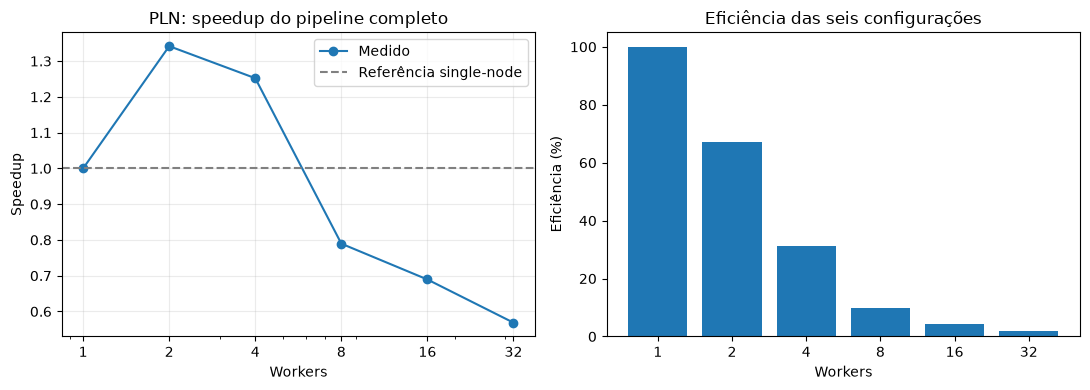

In [11]:
workers = [int(r['nprocs']) for r in rows]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(workers, [r['speedup'] for r in rows], 'o-', label='Medido')
axes[0].axhline(1, color='gray', linestyle='--', label='Referência single-node')
axes[0].set(xscale='log', xlabel='Workers', ylabel='Speedup', title='PLN: speedup do pipeline completo')
axes[0].set_xticks(workers, [str(w) for w in workers])
axes[0].legend()
axes[0].grid(alpha=.25)
axes[1].bar([str(w) for w in workers], [100*r['efficiency'] for r in rows])
axes[1].set(xlabel='Workers', ylabel='Eficiência (%)', title='Eficiência das seis configurações')
fig.tight_layout()
plt.show()

## 8. Estatísticas do corpus

Além das métricas de desempenho, o pipeline produz estatísticas para descrever o corpus após o pré-processamento e verificar se diferentes quantidades de workers geram resultados equivalentes.

No corpus completo foram processados **129.098 documentos**, resultando em:

- **47.801 termos únicos** no vocabulário;
- **1.607.559 valores TF-IDF não nulos**;
- **100 documentos com vetor zero** após a remoção de stopwords.

Como todas as execuções utilizam o mesmo dataset e a mesma implementação, essas estatísticas devem permanecer iguais independentemente da quantidade de workers.

### Distribuição do tamanho dos documentos

O tamanho dos documentos foi registrado antes e depois da remoção das stopwords:

| Medida | Antes | Depois |
|---|---:|---:|
| Mínimo | 0 | 0 |
| Máximo | 795 | 475 |
| Média | 22,855 | 13,330 |
| Desvio padrão | 21,891 | 12,074 |
| p25 | 11 | 7 |
| Mediana | 16 | 10 |
| p75 | 26 | 15 |
| p90 | 45 | 25 |
| p95 | 61 | 34 |
| p99 | 111 | 61 |

A remoção de stopwords reduz a média de aproximadamente **22,9 para 13,3 tokens** e a mediana de **16 para 10**.

A diferença entre média e mediana indica uma distribuição assimétrica: a maior parte das avaliações é curta, enquanto alguns documentos mais longos aumentam a média.

Os histogramas completos dessas distribuições são armazenados nos arquivos `statistics.json`.

### Termos com maior soma de TF-IDF

O pipeline também calcula os termos com maior **soma global de TF-IDF normalizado**:

| Termo | Soma TF-IDF | Frequência documental | IDF |
|---|---:|---:|---:|
| produto | 7209,918 | 59.191 | 1,779793 |
| recomendo | 4297,025 | 24.199 | 2,674227 |
| bom | 4212,728 | 22.871 | 2,730666 |
| entrega | 3952,492 | 21.508 | 2,792108 |
| prazo | 3237,764 | 15.434 | 3,123942 |
| qualidade | 3206,270 | 15.973 | 3,089617 |
| chegou | 3074,684 | 15.314 | 3,131747 |
| excelente | 3039,266 | 13.931 | 3,226391 |
| antes | 2688,986 | 12.237 | 3,356034 |
| bem | 2637,416 | 15.049 | 3,149202 |

Os resultados são coerentes com o contexto de avaliações de e-commerce, destacando termos relacionados a produto, qualidade e entrega.

Esse ranking não corresponde apenas ao maior IDF: ele considera frequência no documento, frequência documental, IDF e normalização L2.

### Consistência entre execuções

As diferentes execuções devem alterar apenas o **tempo de processamento**, e não o resultado do pipeline.

A validação realizada confirmou equivalência entre vocabulários, estatísticas e matrizes CSR produzidas nas diferentes repetições. Também foram verificados:

- os **129.098 IDs únicos**;
- a consistência das 128 partições;
- a normalização L2 das linhas não vazias;
- **2.176 comparações** entre matrizes de execuções distintas.

Com isso, podemos tratar as diferentes configurações como execuções equivalentes do mesmo problema e concentrar a análise seguinte nas diferenças de desempenho.

In [12]:
stats = json.loads((EVIDENCIAS / 'w01-r1/statistics.json').read_text())
for workers in LAYOUT:
    for repetition in (1, 2, 3):
        assert json.loads((EVIDENCIAS / f'w{workers:02d}-r{repetition}/statistics.json').read_text()) == stats
print('Documentos:', stats['documents'])
print('Vocabulário:', stats['vocabulary_size'])
print('Valores não nulos:', stats['nonzero'])
print('Vetores vazios após stopwords:', stats['empty_after_stopwords'])
length_table = '| Medida | Antes das stopwords | Depois das stopwords |\n| --- | ---: | ---: |\n'
for key in ['min', 'max', 'mean', 'std']:
    length_table += f"| {key} | {stats['lengths_before_stopwords'][key]:.3f} | {stats['lengths_after_stopwords'][key]:.3f} |\n"
for key in ['p25', 'p50', 'p75', 'p90', 'p95', 'p99']:
    length_table += f"| {key} | {stats['lengths_before_stopwords']['quantiles'][key]:.3f} | {stats['lengths_after_stopwords']['quantiles'][key]:.3f} |\n"
display(Markdown(length_table))
terms_table = '| Termo | Soma TF-IDF | DF | IDF |\n| --- | ---: | ---: | ---: |\n'
terms_table += '\n'.join(f"| {r['term']} | {r['sum_tfidf']:.3f} | {r['document_frequency']} | {r['idf']:.6f} |" for r in stats['top_tfidf'][:10])
display(Markdown(terms_table))
validation = json.loads((EVIDENCIAS / 'validation.json').read_text())
assert validation['status'] == 'passed'
print('Validação histórica:', validation)

Documentos: 129098
Vocabulário: 47801
Valores não nulos: 1607559
Vetores vazios após stopwords: 100


| Medida | Antes das stopwords | Depois das stopwords |
| --- | ---: | ---: |
| min | 0.000 | 0.000 |
| max | 795.000 | 475.000 |
| mean | 22.855 | 13.330 |
| std | 21.891 | 12.074 |
| p25 | 11.000 | 7.000 |
| p50 | 16.000 | 10.000 |
| p75 | 26.000 | 15.000 |
| p90 | 45.000 | 25.000 |
| p95 | 61.000 | 34.000 |
| p99 | 111.000 | 61.000 |


| Termo | Soma TF-IDF | DF | IDF |
| --- | ---: | ---: | ---: |
| produto | 7209.918 | 59191 | 1.779793 |
| recomendo | 4297.025 | 24199 | 2.674227 |
| bom | 4212.728 | 22871 | 2.730666 |
| entrega | 3952.492 | 21508 | 2.792108 |
| prazo | 3237.764 | 15434 | 3.123942 |
| qualidade | 3206.270 | 15973 | 3.089617 |
| chegou | 3074.684 | 15314 | 3.131747 |
| excelente | 3039.266 | 13931 | 3.226391 |
| antes | 2688.986 | 12237 | 3.356034 |
| bem | 2637.416 | 15049 | 3.149202 |

Validação histórica: {'status': 'passed', 'repetitions': 18, 'partitions_per_run': 128, 'cross_run_partition_comparisons': 2176, 'statistics_identical': True, 'vocabulary_identical': True, 'csr_arrays_identical': True, 'l2_rows_valid': True, 'unique_documents': 129098, 'vocabulary_size': 47801, 'nonzero': 1607559, 'zero_rows': 100, 'vocabulary_sha256': '36cd7455fa87684466305f3134a172b89304dd63070caede8cc345dbec7d29e7'}


## 9. Análise e limites

Depois de validar as execuções e confirmar que todas produziram resultados equivalentes de PLN, analisamos o comportamento do pipeline com o aumento da quantidade de workers.

O menor tempo mediano foi obtido com **2 workers**, com **4,735173 s**, contra **6,353340 s** com 1 worker. Isso representa um speedup de aproximadamente:

\[
S = \frac{6,353340}{4,735173} \approx 1,342
\]

Portanto, o paralelismo trouxe ganho inicialmente, mas o desempenho não apresentou crescimento linear conforme novos workers foram adicionados.

### Comportamento do speedup

A partir de 2 workers, aumentar o paralelismo não resultou em redução proporcional do tempo total.

Isso ocorre porque o pipeline possui etapas distribuíveis, mas também depende de operações globais, como:

- agregação das frequências documentais;
- construção do vocabulário e do IDF;
- broadcast dessas estruturas;
- comunicação e sincronização entre workers;
- leitura e escrita no NFS.

Quando o processamento passa a envolver vários nós, os custos de comunicação pela rede também se tornam mais relevantes.

Assim, o ganho obtido com a divisão do processamento passa a competir com o overhead necessário para coordenar a execução distribuída.

### I/O e `t_calc`

O benchmark inclui a leitura dos shards no NFS e a escrita das matrizes NPZ. Portanto, o tempo observado representa o pipeline completo, e não apenas os cálculos de tokenização e TF-IDF.

Da mesma forma, `t_calc` é definido como:

\[
t_{calc}=t_{total}-t_{serial}
\]

e não representa exclusivamente tempo de CPU. Ele também pode incluir comunicação, I/O, sincronização, serialização e espera entre workers.

### Strong scaling

O experimento é um caso de **strong scaling**, pois os mesmos **129.098 documentos** são processados em todas as configurações enquanto aumentamos a quantidade de recursos.

Isso significa que cada worker recebe uma parcela progressivamente menor de uma carga fixa. Para este corpus, formado principalmente por textos curtos, o trabalho distribuído torna-se pequeno em relação ao overhead de coordenação.

Por isso, os resultados não devem ser generalizados para datasets muito maiores ou tarefas computacionalmente mais pesadas.

### Configuração com 32 workers

Na configuração de 32 workers são utilizados quatro nós com oito workers por nó, fazendo uso de **SMT/Hyper-Threading**.

Assim, a mudança de 16 para 32 workers não representa uma duplicação dos cores físicos disponíveis. Parte dos workers compartilha recursos internos dos processadores, o que também pode limitar os ganhos de desempenho.

### Limitações do experimento

Algumas limitações devem ser consideradas:

- foram realizadas apenas três repetições por configuração;
- a ordem das configurações foi fixa;
- não houve limpeza explícita dos caches entre execuções;
- não foram calculados intervalos de confiança;
- a referência com 1 worker ainda utiliza Dask, incluindo scheduler e demais overheads da arquitetura distribuída.

Apesar disso, utilizar a mesma implementação em todas as configurações mantém a comparação controlada, alterando principalmente a quantidade de workers e nós.

### Validação dos resultados

Além dos tempos, foi verificado que o paralelismo não alterou o resultado do pipeline.

As 18 execuções produziram **2.304 arquivos de matriz**:

\[
18 \times 128 = 2304
\]

Também foram realizadas **2.176 comparações entre partições de execuções distintas**, verificando equivalência dos arrays CSR, IDs dos documentos e normalização L2 dos vetores não vazios.

### Conclusão

Para o corpus, implementação e infraestrutura avaliados, **2 workers apresentaram o melhor tempo mediano**, com speedup de **1,342**.

A partir desse ponto, os ganhos de paralelização não compensaram os custos adicionais de comunicação, coordenação, broadcast e I/O.

Esse resultado não indica que Dask ou o aumento de workers sejam desvantajosos em geral. Ele mostra que, neste cenário de **carga fixa e documentos relativamente curtos**, o overhead distribuído passou a dominar rapidamente o tempo de execução.

O experimento reforça que o benefício do paralelismo depende do equilíbrio entre quantidade de trabalho distribuível e custo da própria distribuição.